<a href="https://colab.research.google.com/github/Berserker268/Employee-Attrition-Prediction/blob/main/Employee_Attrition_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import kagglehub

path = kagglehub.dataset_download("pavansubhasht/ibm-hr-analytics-attrition-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ibm-hr-analytics-attrition-dataset' dataset.
Path to dataset files: /kaggle/input/ibm-hr-analytics-attrition-dataset


In [ ]:
import os

path = "/kaggle/input/ibm-hr-analytics-attrition-dataset"
print(os.listdir(path))


['WA_Fn-UseC_-HR-Employee-Attrition.csv']


In [ ]:
import pandas as pd

df = pd.read_csv("/kaggle/input/ibm-hr-analytics-attrition-dataset/WA_Fn-UseC_-HR-Employee-Attrition.csv")

print(df.shape)
print(df.head())
print(df.info())

(1470, 35)
   Age Attrition     BusinessTravel  DailyRate              Department  \
0   41       Yes      Travel_Rarely       1102                   Sales   
1   49        No  Travel_Frequently        279  Research & Development   
2   37       Yes      Travel_Rarely       1373  Research & Development   
3   33        No  Travel_Frequently       1392  Research & Development   
4   27        No      Travel_Rarely        591  Research & Development   

   DistanceFromHome  Education EducationField  EmployeeCount  EmployeeNumber  \
0                 1          2  Life Sciences              1               1   
1                 8          1  Life Sciences              1               2   
2                 2          2          Other              1               4   
3                 3          4  Life Sciences              1               5   
4                 2          1        Medical              1               7   

   ...  RelationshipSatisfaction StandardHours  StockOptionLeve

In [ ]:
print(df['Attrition'].value_counts())
print(df['Attrition'].value_counts(normalize=True) * 100)

Attrition
No     1233
Yes     237
Name: count, dtype: int64
Attrition
No     83.877551
Yes    16.122449
Name: proportion, dtype: float64


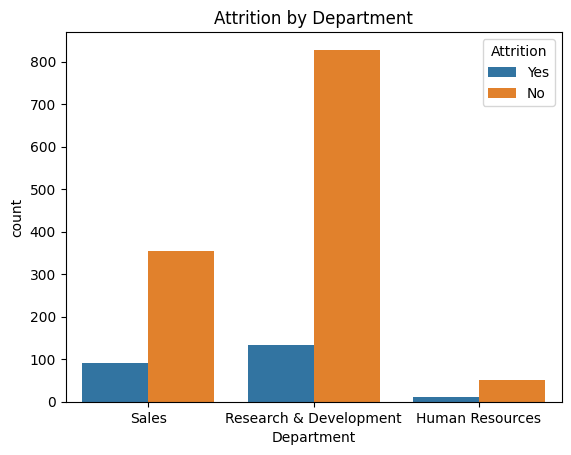

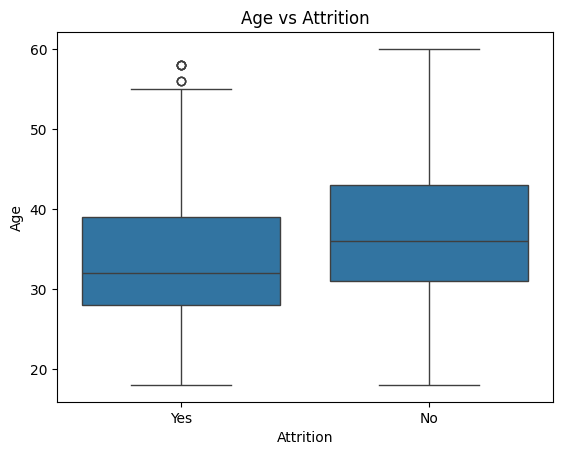

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.countplot(data=df, x='Department', hue='Attrition')
plt.title("Attrition by Department")
plt.show()

sns.boxplot(data=df, x='Attrition', y='Age')
plt.title("Age vs Attrition")
plt.show()

In [ ]:
df = df.drop(['EmployeeNumber', 'EmployeeCount', 'Over18', 'StandardHours'], axis=1)

In [ ]:
print("Missing Values:")
print(df.isnull().sum())
print("\nTotal missing:", df.isnull().sum().sum())

Missing Values:
Age                         0
Attrition                   0
BusinessTravel              0
DailyRate                   0
Department                  0
DistanceFromHome            0
Education                   0
EducationField              0
EnvironmentSatisfaction     0
Gender                      0
HourlyRate                  0
JobInvolvement              0
JobLevel                    0
JobRole                     0
JobSatisfaction             0
MaritalStatus               0
MonthlyIncome               0
MonthlyRate                 0
NumCompaniesWorked          0
OverTime                    0
PercentSalaryHike           0
PerformanceRating           0
RelationshipSatisfaction    0
StockOptionLevel            0
TotalWorkingYears           0
TrainingTimesLastYear       0
WorkLifeBalance             0
YearsAtCompany              0
YearsInCurrentRole          0
YearsSinceLastPromotion     0
YearsWithCurrManager        0
dtype: int64

Total missing: 0


In [ ]:
print("Unique values per column:")
for col in df.columns:
    print(f"{col}: {df[col].nunique()} unique -> {df[col].unique()[:5]}")

Unique values per column:
Age: 43 unique -> [41 49 37 33 27]
Attrition: 2 unique -> ['Yes' 'No']
BusinessTravel: 3 unique -> ['Travel_Rarely' 'Travel_Frequently' 'Non-Travel']
DailyRate: 886 unique -> [1102  279 1373 1392  591]
Department: 3 unique -> ['Sales' 'Research & Development' 'Human Resources']
DistanceFromHome: 29 unique -> [ 1  8  2  3 24]
Education: 5 unique -> [2 1 4 3 5]
EducationField: 6 unique -> ['Life Sciences' 'Other' 'Medical' 'Marketing' 'Technical Degree']
EnvironmentSatisfaction: 4 unique -> [2 3 4 1]
Gender: 2 unique -> ['Female' 'Male']
HourlyRate: 71 unique -> [94 61 92 56 40]
JobInvolvement: 4 unique -> [3 2 4 1]
JobLevel: 5 unique -> [2 1 3 4 5]
JobRole: 9 unique -> ['Sales Executive' 'Research Scientist' 'Laboratory Technician'
 'Manufacturing Director' 'Healthcare Representative']
JobSatisfaction: 4 unique -> [4 2 3 1]
MaritalStatus: 3 unique -> ['Single' 'Married' 'Divorced']
MonthlyIncome: 1349 unique -> [5993 5130 2090 2909 3468]
MonthlyRate: 1427 uniqu

In [ ]:
print("Duplicate rows:", df.duplicated().sum())

Duplicate rows: 0


In [ ]:
print(df.describe())

               Age    DailyRate  DistanceFromHome    Education  \
count  1470.000000  1470.000000       1470.000000  1470.000000   
mean     36.923810   802.485714          9.192517     2.912925   
std       9.135373   403.509100          8.106864     1.024165   
min      18.000000   102.000000          1.000000     1.000000   
25%      30.000000   465.000000          2.000000     2.000000   
50%      36.000000   802.000000          7.000000     3.000000   
75%      43.000000  1157.000000         14.000000     4.000000   
max      60.000000  1499.000000         29.000000     5.000000   

       EnvironmentSatisfaction   HourlyRate  JobInvolvement     JobLevel  \
count              1470.000000  1470.000000     1470.000000  1470.000000   
mean                  2.721769    65.891156        2.729932     2.063946   
std                   1.093082    20.329428        0.711561     1.106940   
min                   1.000000    30.000000        1.000000     1.000000   
25%                   2.0

In [ ]:
from sklearn.preprocessing import LabelEncoder

df['Attrition'] = df['Attrition'].map({'Yes': 1, 'No': 0})

cat_cols = df.select_dtypes(include='object').columns
le = LabelEncoder()
for col in cat_cols:
    df[col] = le.fit_transform(df[col])

print(df['Attrition'].value_counts())
print("NaN count:", df['Attrition'].isna().sum())

Attrition
0    1233
1     237
Name: count, dtype: int64
NaN count: 0


In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop('Attrition', axis=1)
y = df['Attrition']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(X_train.shape, X_test.shape)

(1176, 30) (294, 30)


In [ ]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
from xgboost import XGBClassifier
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

model = XGBClassifier(scale_pos_weight=5, random_state=42, eval_metric='logloss')
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

              precision    recall  f1-score   support

           0       0.88      0.95      0.91       247
           1       0.54      0.30      0.38        47

    accuracy                           0.85       294
   macro avg       0.71      0.62      0.65       294
weighted avg       0.82      0.85      0.83       294

ROC-AUC: 0.7708674304418985


In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(class_weight='balanced', random_state=42, n_estimators=100)
rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_test)
print("=== Random Forest ===")
print(classification_report(y_test, rf_pred))
print("ROC-AUC:", roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]))

=== Random Forest ===
              precision    recall  f1-score   support

           0       0.85      0.98      0.91       247
           1       0.44      0.09      0.14        47

    accuracy                           0.84       294
   macro avg       0.65      0.53      0.53       294
weighted avg       0.78      0.84      0.79       294

ROC-AUC: 0.7596261521233525


In [ ]:
from sklearn.linear_model import LogisticRegression

lr_model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
lr_model.fit(X_train, y_train)

lr_pred = lr_model.predict(X_test)
print("=== Logistic Regression ===")
print(classification_report(y_test, lr_pred))
print("ROC-AUC:", roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1]))

=== Logistic Regression ===
              precision    recall  f1-score   support

           0       0.94      0.75      0.84       247
           1       0.37      0.77      0.50        47

    accuracy                           0.75       294
   macro avg       0.66      0.76      0.67       294
weighted avg       0.85      0.75      0.78       294

ROC-AUC: 0.8073908174692048


                 Model   ROC-AUC
2  Logistic Regression  0.807391
0              XGBoost  0.770867
1        Random Forest  0.759626


/tmp/ipykernel_25381/4035746779.py:14: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette='viridis')


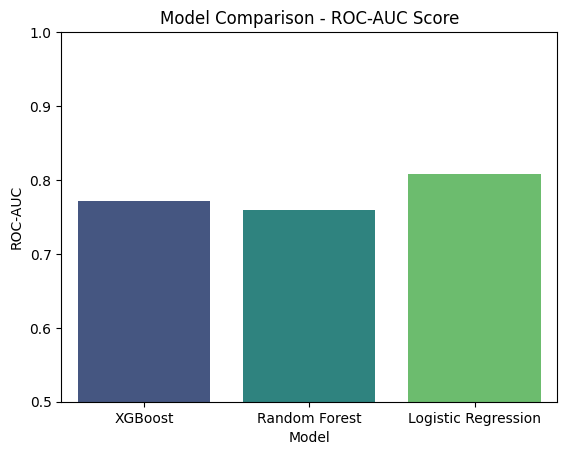

In [ ]:
results = {
    'Model': ['XGBoost', 'Random Forest', 'Logistic Regression'],
    'ROC-AUC': [
        roc_auc_score(y_test, model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, rf_model.predict_proba(X_test)[:,1]),
        roc_auc_score(y_test, lr_model.predict_proba(X_test)[:,1])
    ]
}

results_df = pd.DataFrame(results)
print(results_df.sort_values('ROC-AUC', ascending=False))

# Bar chart
sns.barplot(data=results_df, x='Model', y='ROC-AUC', palette='viridis')
plt.title("Model Comparison - ROC-AUC Score")
plt.ylim(0.5, 1.0)
plt.show()

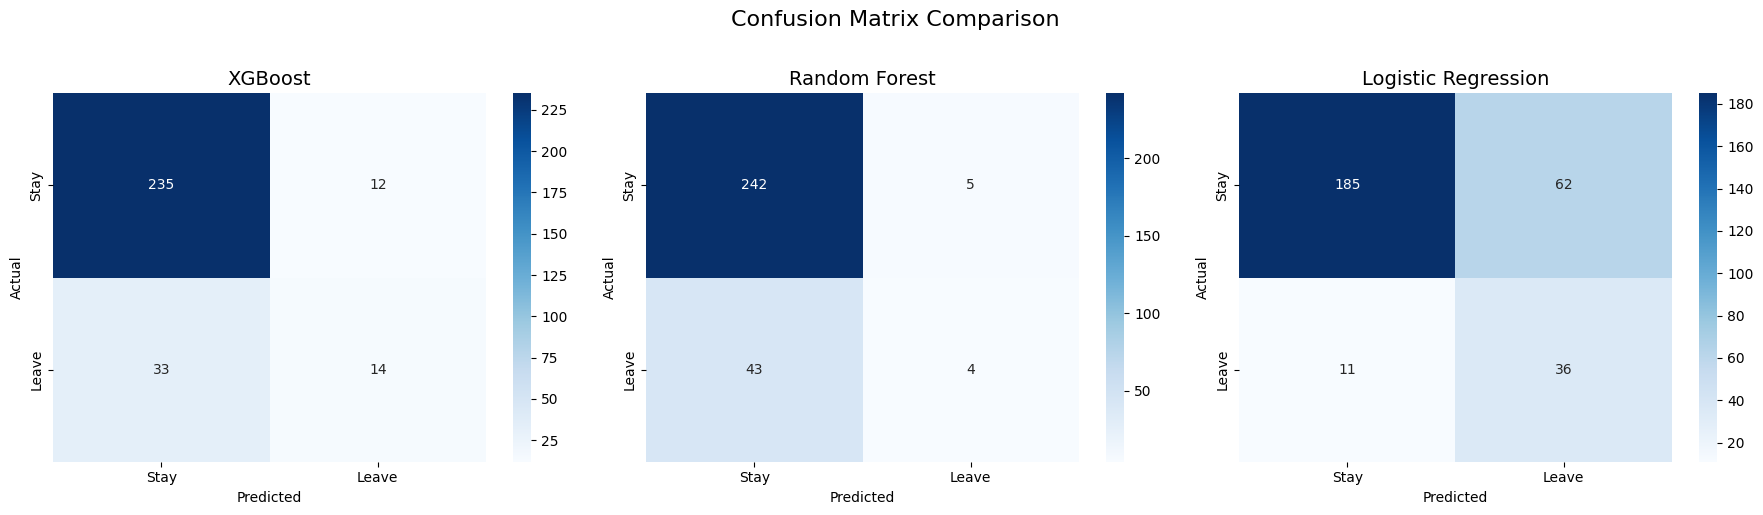

In [ ]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import seaborn as sns

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = [
    (model, y_pred, "XGBoost"),
    (rf_model, rf_pred, "Random Forest"),
    (lr_model, lr_pred, "Logistic Regression")
]

for ax, (m, pred, name) in zip(axes, models):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Stay', 'Leave'],
                yticklabels=['Stay', 'Leave'],
                ax=ax)
    ax.set_title(f"{name}", fontsize=14)
    ax.set_ylabel("Actual")
    ax.set_xlabel("Predicted")

plt.suptitle("Confusion Matrix Comparison", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
import shap

explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X_test)

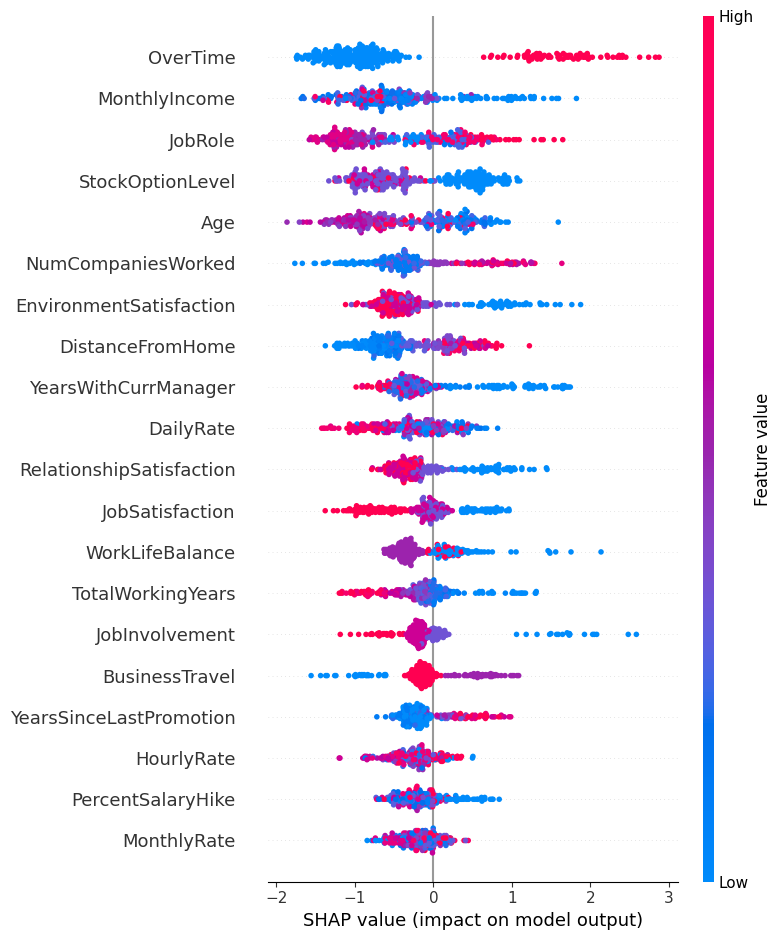

In [ ]:
shap.summary_plot(shap_values, X_test,
                  feature_names=df.drop('Attrition', axis=1).columns.tolist())

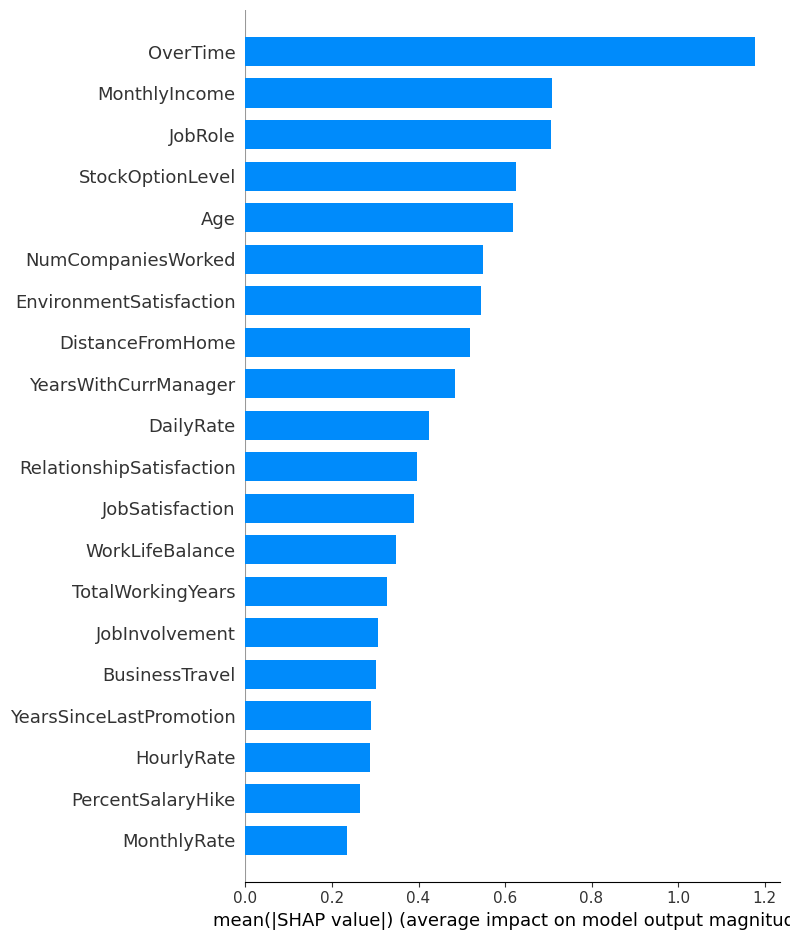

In [ ]:
shap.summary_plot(shap_values, X_test,
                  feature_names=df.drop('Attrition', axis=1).columns.tolist(),
                  plot_type='bar')

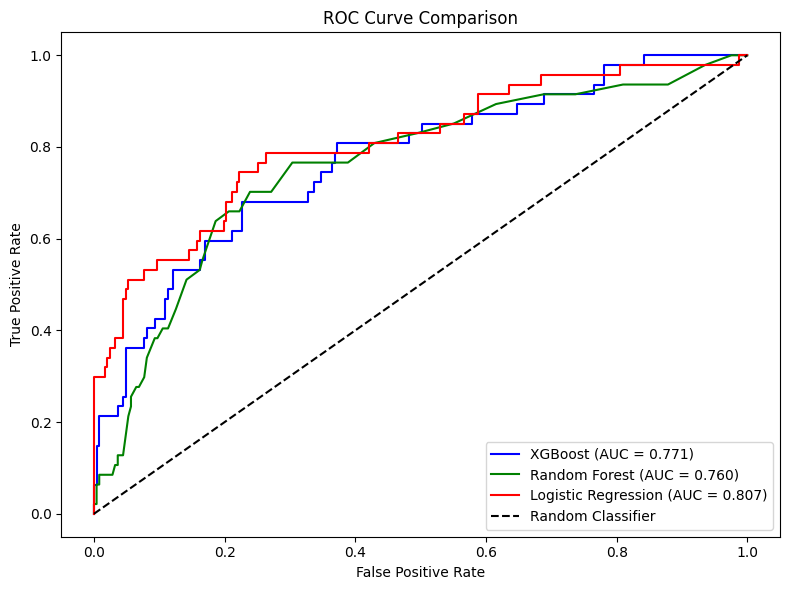

In [ ]:
from sklearn.metrics import roc_curve, auc

plt.figure(figsize=(8, 6))

for m, name, color in [
    (model, 'XGBoost', 'blue'),
    (rf_model, 'Random Forest', 'green'),
    (lr_model, 'Logistic Regression', 'red')
]:
    fpr, tpr, _ = roc_curve(y_test, m.predict_proba(X_test)[:,1])
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, color=color, label=f'{name} (AUC = {roc_auc:.3f})')

plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve Comparison')
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

In [ ]:
!pip install gradio -q

import gradio as gr
import numpy as np
import pandas as pd

feature_names = df.drop('Attrition', axis=1).columns.tolist()

def predict_attrition(Age, BusinessTravel, DailyRate, Department, DistanceFromHome,
                       Education, EducationField, EnvironmentSatisfaction, Gender,
                       HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction,
                       MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked,
                       OverTime, PercentSalaryHike, PerformanceRating,
                       RelationshipSatisfaction, StockOptionLevel, TotalWorkingYears,
                       TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany,
                       YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager):

    input_data = pd.DataFrame([[Age, BusinessTravel, DailyRate, Department, DistanceFromHome,
                                  Education, EducationField, EnvironmentSatisfaction, Gender,
                                  HourlyRate, JobInvolvement, JobLevel, JobRole, JobSatisfaction,
                                  MaritalStatus, MonthlyIncome, MonthlyRate, NumCompaniesWorked,
                                  OverTime, PercentSalaryHike, PerformanceRating,
                                  RelationshipSatisfaction, StockOptionLevel, TotalWorkingYears,
                                  TrainingTimesLastYear, WorkLifeBalance, YearsAtCompany,
                                  YearsInCurrentRole, YearsSinceLastPromotion, YearsWithCurrManager]],
                                columns=feature_names)

    input_scaled = scaler.transform(input_data)
    prob = model.predict_proba(input_scaled)[0][1]
    risk = "🔴 High Risk" if prob > 0.5 else "🟢 Low Risk"
    return f"{risk} — Attrition Probability: {prob:.1%}"

demo = gr.Interface(
    fn=predict_attrition,
    inputs=[
        gr.Slider(18, 60, value=35, label="Age"),
        gr.Slider(0, 2, step=1, value=1, label="BusinessTravel (0=Non, 1=Rarely, 2=Frequently)"),
        gr.Slider(100, 1500, value=800, label="DailyRate"),
        gr.Slider(0, 2, step=1, value=0, label="Department (0=HR, 1=R&D, 2=Sales)"),
        gr.Slider(1, 29, value=5, label="DistanceFromHome"),
        gr.Slider(1, 5, step=1, value=3, label="Education"),
        gr.Slider(0, 5, step=1, value=2, label="EducationField"),
        gr.Slider(1, 4, step=1, value=3, label="EnvironmentSatisfaction"),
        gr.Slider(0, 1, step=1, value=0, label="Gender (0=Female, 1=Male)"),
        gr.Slider(30, 100, value=65, label="HourlyRate"),
        gr.Slider(1, 4, step=1, value=3, label="JobInvolvement"),
        gr.Slider(1, 5, step=1, value=2, label="JobLevel"),
        gr.Slider(0, 8, step=1, value=4, label="JobRole"),
        gr.Slider(1, 4, step=1, value=3, label="JobSatisfaction"),
        gr.Slider(0, 2, step=1, value=1, label="MaritalStatus (0=Divorced, 1=Married, 2=Single)"),
        gr.Slider(1000, 20000, value=6000, label="MonthlyIncome"),
        gr.Slider(2000, 27000, value=14000, label="MonthlyRate"),
        gr.Slider(0, 9, step=1, value=2, label="NumCompaniesWorked"),
        gr.Slider(0, 1, step=1, value=0, label="OverTime (0=No, 1=Yes)"),
        gr.Slider(10, 25, value=15, label="PercentSalaryHike"),
        gr.Slider(3, 4, step=1, value=3, label="PerformanceRating"),
        gr.Slider(1, 4, step=1, value=3, label="RelationshipSatisfaction"),
        gr.Slider(0, 3, step=1, value=1, label="StockOptionLevel"),
        gr.Slider(0, 40, value=10, label="TotalWorkingYears"),
        gr.Slider(0, 6, step=1, value=3, label="TrainingTimesLastYear"),
        gr.Slider(1, 4, step=1, value=3, label="WorkLifeBalance"),
        gr.Slider(0, 40, value=5, label="YearsAtCompany"),
        gr.Slider(0, 18, value=3, label="YearsInCurrentRole"),
        gr.Slider(0, 15, value=2, label="YearsSinceLastPromotion"),
        gr.Slider(0, 17, value=3, label="YearsWithCurrManager"),
    ],
    outputs=gr.Text(label="Prediction"),
    title="🧑‍💼 Employee Attrition Predictor",
    description="Adjust employee details to predict attrition risk using XGBoost"
)

demo.launch()

It looks like you are running Gradio on a hosted Jupyter notebook, which requires `share=True`. Automatically setting `share=True` (you can turn this off by setting `share=False` in `launch()` explicitly).

Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://9765180dca6e438912.gradio.live

This share link expires in 1 week. For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
